In [ ]:
import pandas as pd
import numpy as np
import statistics as s
import scipy as stat

In [ ]:
df = pd.read_excel('df_final.xlsx')
pop = pd.read_excel("pop_ceara.xlsx")
urb = pd.read_excel("urbanização.xlsx")
pib_mil = pd.read_excel("pib_mil.xlsx")
saude = pd.read_excel('unidades de saúde.xlsx')
densidade = pd.read_excel('dens_demo.xlsx')

In [ ]:
import pandas as pd
import unicodedata

def normalizar_nome(nome):
    if not isinstance(nome, str): return nome
    # Remove acentos e converte para maiúsculo sem espaços extras
    nfkd_form = unicodedata.normalize('NFKD', nome)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)]).strip().upper()

# Limpar e normalizar os nomes nos dataframes de origem
pib_mil['Município'] = pib_mil['Município'].str.replace(' (CE)', '', regex=False).apply(normalizar_nome)
df['Município'] = df['Município'].apply(normalizar_nome)
pop['Município'] = pop['Município'].apply(normalizar_nome)
urb['Município'] = urb['Município'].apply(normalizar_nome)
saude['Município'] = saude['Município'].apply(normalizar_nome)
densidade['Município'] = densidade['Município'].apply(normalizar_nome)

# Realizar o merge sucessivo
df_final = df.merge(pop, on='Município', how='left')
df_final = df_final.merge(urb, on='Município', how='left')
df_final = df_final.merge(pib_mil, on='Município', how='left')
df_final = df_final.merge(saude, on='Município', how='left')
df_final = df_final.merge(densidade, on='Município', how='left')

# Renomear colunas para clareza
df_final = df_final.rename(columns={
    '2022_x': 'Taxa de Urbanização (%)',
    '2022_y': 'PIB Municipal (mil R$)'
})

# Verificar a contagem e se ainda há NAs significativos
num_municipios = df_final['Município'].nunique()
nas_detectados = df_final['Taxa de Urbanização (%)'].isna().sum()

print(f'Total de municípios únicos: {num_municipios}')
print(f'Municípios sem dados após normalização: {nas_detectados}')

display(df_final.head())

Total de municípios únicos: 184
Municípios sem dados após normalização: Taxa de Urbanização (%)    0
Taxa de Urbanização (%)    0
dtype: int64


,Unnamed: 0,Município,população_x,Ligação sem a rede de agua,Casos De dengue em 2022,Taxa de incidencia,população_y,Taxa de Urbanização (%),PIB Municipal (mil R$),população,Taxa de Urbanização (%),PIB Municipal (mil R$),unis_pormil,densidade_demo
0,0,ABAIARA,10038,34.99,4,0.398486,10038,55.509066,126794,10038,55.509066,126794,0.896593,55.51
1,1,ACARAPE,14027,12.32,5,0.356455,14027,62.429600,183507,14027,62.429600,183507,1.069366,107.90
2,2,ACARAU,65264,23.65,22,0.337092,65264,44.272493,1184672,65264,44.272493,1184672,0.597573,76.92
3,3,ACOPIARA,44962,31.14,23,0.511543,44962,54.561630,604192,44962,54.561630,604192,0.600507,19.95
4,4,AIUABA,14076,35.61,212,15.061097,14076,40.323956,146744,14076,40.323956,146744,0.639386,5.77


In [ ]:
del df_final['população_x']
del df_final['população_y']
del df_final['Unnamed: 0']

In [ ]:
df_final

,Município,Ligação sem a rede de agua,Casos De dengue em 2022,Taxa de incidencia,Taxa de Urbanização (%),PIB Municipal (mil R$),população,Taxa de Urbanização (%),PIB Municipal (mil R$),unis_pormil,densidade_demo
0,ABAIARA,34.99,4,0.398486,55.509066,126794,10038,55.509066,126794,0.896593,55.51
1,ACARAPE,12.32,5,0.356455,62.429600,183507,14027,62.429600,183507,1.069366,107.90
2,ACARAU,23.65,22,0.337092,44.272493,1184672,65264,44.272493,1184672,0.597573,76.92
3,ACOPIARA,31.14,23,0.511543,54.561630,604192,44962,54.561630,604192,0.600507,19.95
4,AIUABA,35.61,212,15.061097,40.323956,146744,14076,40.323956,146744,0.639386,5.77
...,...,...,...,...,...,...,...,...,...,...,...
179,URUBURETAMA,22.33,8,0.396255,75.179553,460850,20189,75.179553,460850,0.891575,203.11
180,URUOCA,22.04,3,0.218245,58.184199,238457,13746,58.184199,238457,0.872981,19.70
181,VARJOTA,7.68,3,0.165700,75.067661,404964,18105,75.067661,404964,0.662800,101.01
182,VARZEA ALEGRE,21.18,26,0.666940,61.407244,502914,38984,61.407244,502914,0.461728,46.97


In [ ]:
del df_final['PIB Municipal (mil R$)']
del df_final['Taxa de Urbanização (%)']

In [ ]:
df['Taxa de incidencia'] = (df['confirmado'] / df_final['população']) * 1000

## Medidas de Tendência Central

In [ ]:
media = s.mean(df_final['Taxa de incidencia'])

print(f"a média da taxa de incidência é de {media}")

a média da taxa de incidência é de 3.731246255466889


In [ ]:
mediana = s.median(df_final['Taxa de incidencia'])

print(f"a mediana da taxa de incidência é de {mediana}")

a mediana da taxa de incidência é de 1.1537353941292419


## Medidas de Variabilidade

In [ ]:
amplitude = max(df['Taxa de incidencia']) - min(df['Taxa de incidencia'])

print(f"a amplitude da taxa de incidência é de {amplitude}")

a amplitude da taxa de incidência é de 41.25089094796864


In [ ]:
variancia = s.pvariance(df_final['Taxa de incidencia'])

print(f"a variância da taxa de incidência é de {variancia}")

a variância da taxa de incidência é de 39.1343518899877


In [ ]:
desv = s.pstdev(df_final['Taxa de incidencia'])

print(f"o desvio padrão da taxa de incidência é de {desv}")

o desvio padrão da taxa de incidência é de 6.255745510327902


In [ ]:
terceiro_momento = stat.stats.skew(df_final['Taxa de incidencia'])

print(f"O terceiro momento (assimetria) da taxa de incidência é de {terceiro_momento:.2f}")

O terceiro momento (assimetria) da taxa de incidência é de 3.44


In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_final['Taxa de incidencia'].quantile(0.25)
Q3 = df_final['Taxa de incidencia'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define outlier bounds
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Identify outliers
outliers = df_final[(df_final['Taxa de incidencia'] < lower_bound) | (df_final['Taxa de incidencia'] > upper_bound)]

print(f"Limiar inferior para outliers: {lower_bound:.2f}")
print(f"Limiar superior para outliers: {upper_bound:.2f}")

if not outliers.empty:
    print("\nValores Outliers (Município e Taxa de Incidência):")
    display(outliers[['Município', 'Taxa de incidencia']])
else:
    print("\nNão foram identificados outliers usando o método IQR.")

Limiar inferior para outliers: -6.08
Limiar superior para outliers: 11.08

Valores Outliers (Município e Taxa de Incidência):


,Município,Taxa de incidencia
4,AIUABA,15.061097
16,ARATUBA,41.250891
28,BELA CRUZ,15.865751
30,BREJO SANTO,12.370327
46,CHORO,13.621729
51,CROATA,27.172359
65,GROAIRAS,33.913841
73,IBICUITINGA,11.196279
74,ICAPUI,26.267905
101,LIMOEIRO DO NORTE,21.625252


In [ ]:
curtose = stat.stats.kurtosis(df_final['Taxa de incidencia'], fisher = True)

print(f"A curtose da taxa de incidência é de {curtose}")

A curtose da taxa de incidência é de 14.327616306651272


### Gráficos de Distribuição da Taxa de Incidência

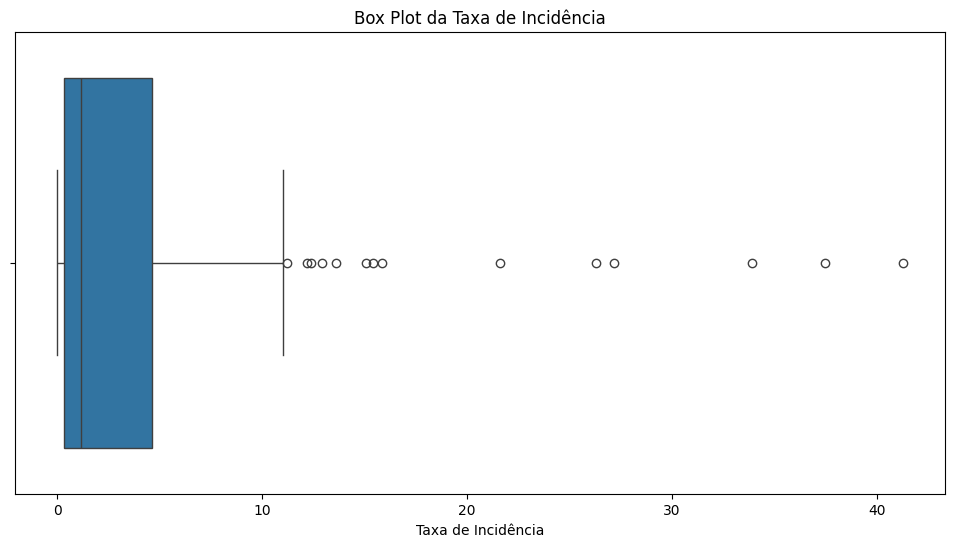

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_final['Taxa de incidencia'])
plt.title('Box Plot da Taxa de Incidência')
plt.xlabel('Taxa de Incidência')
plt.show()

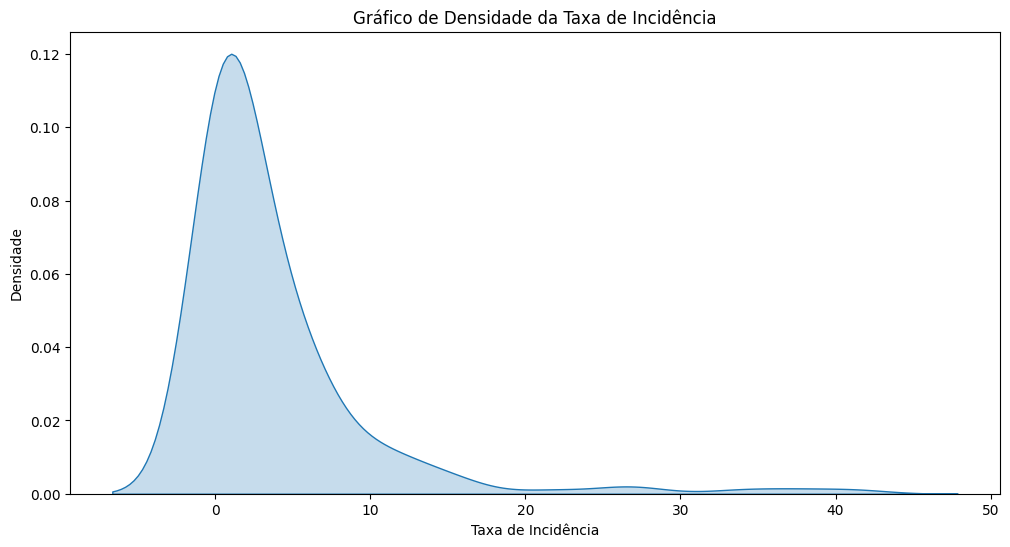

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_final['Taxa de incidencia'], fill=True)
plt.title('Gráfico de Densidade da Taxa de Incidência')
plt.xlabel('Taxa de Incidência')
plt.ylabel('Densidade')
plt.show()

In [ ]:
from google.colab import files
df_final.to_excel('df_final.xlsx')
files.download('df_final.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>